# Ordinary Least Squares (from scratch)

We estimate weights with a numerically stable least-squares solve — mathematically equivalent to

$$w_{LS} = (X^\top X)^{-1} X^\top y$$

when $X$ has full column rank, but implemented via `np.linalg.lstsq` instead of an explicit inverse.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import (
    LeastSquaresRegressor, load_housing_data, prepare_xy, train_val_split, rmse, r2_score
)
plt.rcParams["figure.figsize"] = (10, 5)


In [2]:
train, _ = load_housing_data()
# Classic two-feature demo + richer DEFAULT_FEATURES comparison
X2, y, feats2 = prepare_xy(train, features=["GrLivArea", "YearBuilt"], log_target=True)
X, y_full, feats = prepare_xy(train, log_target=True)
X_tr, X_va, y_tr, y_va = train_val_split(X, y_full, random_state=42)

model = LeastSquaresRegressor().fit(X_tr, y_tr)
pred = model.predict(X_va)
print("Features:", feats)
print(f"Intercept={model.intercept_:.4f}")
print("Coefficients:", dict(zip(feats, model.coef_.round(4))))
print(f"Val RMSE (log)={rmse(y_va, pred):.4f}  R²={r2_score(y_va, pred):.4f}")
print(f"Val RMSE ($)=${rmse(np.expm1(y_va), np.expm1(pred)):,.0f}")


Features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']
Intercept=2.4813
Coefficients: {'OverallQual': np.float64(0.0909), 'GrLivArea': np.float64(0.0002), 'GarageCars': np.float64(0.0724), 'GarageArea': np.float64(0.0001), 'TotalBsmtSF': np.float64(0.0001), '1stFlrSF': np.float64(0.0001), 'FullBath': np.float64(-0.0084), 'TotRmsAbvGrd': np.float64(0.008), 'YearBuilt': np.float64(0.0019), 'YearRemodAdd': np.float64(0.0023)}
Val RMSE (log)=0.1502  R²=0.8289
Val RMSE ($)=$28,151


In [3]:
# Sanity check vs scikit-learn
sk = LinearRegression().fit(X_tr, y_tr)
np.testing.assert_allclose(model.intercept_, sk.intercept_, rtol=1e-6)
np.testing.assert_allclose(model.coef_, sk.coef_, rtol=1e-6)
print("Matches sklearn LinearRegression ✓")


Matches sklearn LinearRegression ✓


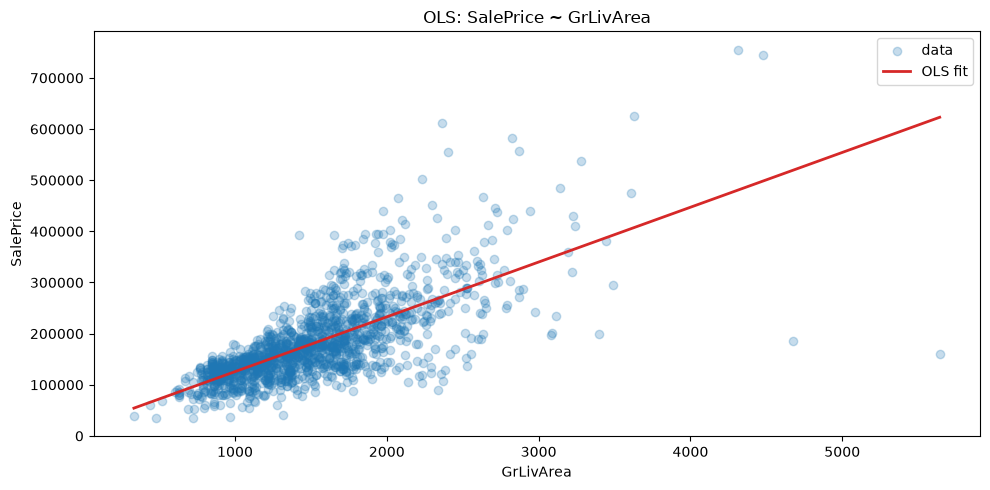

In [4]:
# Simple 1D visualization on GrLivArea
X1, y1, _ = prepare_xy(train, features=["GrLivArea"], log_target=False)
m1 = LeastSquaresRegressor().fit(X1, y1)
grid = np.linspace(X1.min(), X1.max(), 200).reshape(-1, 1)
plt.scatter(X1, y1, alpha=0.25, label="data")
plt.plot(grid, m1.predict(grid), color="#d62828", lw=2, label="OLS fit")
plt.xlabel("GrLivArea"); plt.ylabel("SalePrice"); plt.legend()
plt.title("OLS: SalePrice ~ GrLivArea")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "ols_fit.png", dpi=120)
plt.show()
